# Session 4 Homework — Filters across classes, Gaussian blur, Canny
**George Hanna** · Computer Vision & Speech Recognition (EADA) · dataset: MILK10k

1. **Filters across diagnosis classes**: do edges or textures look different between malignant and benign lesions?
2. **Gaussian blur**: what `sigma` controls in `scipy.ndimage.gaussian_filter`, with experiments.
3. **Canny edge detection**: implemented from scratch as a function and compared with Sobel.

Only images from the **training split** are used (`splits/train.csv`, Milestone 1), so nothing here looks at the
validation or test lesions. Run with *Restart & Run All* (about 1 minute).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image
from scipy import ndimage, stats
from skimage import feature          # only used to check my Canny against a reference implementation

from milk10k import config
from milk10k.visualize import apply_style, CLASS_COLORS

apply_style()
pd.set_option("display.width", 160)
FIG_DIR = config.FIGURES_DIR / "session4_homework"

SOBEL_X = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
SOBEL_Y = SOBEL_X.T                                                    # [[-1,-2,-1],[0,0,0],[1,2,1]]
SHARPEN = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=float)
OUTLINE = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=float)


def load_gray(isic_id):
    """Grayscale image as a float array, values 0-255."""
    return np.asarray(Image.open(config.IMG_DIR / f"{isic_id}.jpg").convert("L"), dtype=float)


def load_rgb(isic_id):
    return np.asarray(Image.open(config.IMG_DIR / f"{isic_id}.jpg").convert("RGB"))


def filt(image, kernel):
    """Same as fast_conv2d from class: correlation with mirror padding, same output size."""
    return ndimage.correlate(image, kernel, mode="reflect")


def sobel_magnitude(image):
    return np.sqrt(filt(image, SOBEL_X) ** 2 + filt(image, SOBEL_Y) ** 2)


def show_and_save(fig, name):
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / name)
    plt.show()

## Part 1 — Filters on lesions from different diagnosis classes

Three benign diagnoses (nevus **NV**, benign keratosis **BKL**, dermatofibroma **DF**) and three malignant ones
(melanoma **MEL**, basal cell carcinoma **BCC**, squamous cell carcinoma / keratoacanthoma **SCCKA**). Dermoscopic
images only (one per lesion), up to 150 per diagnosis, drawn with the project seed (42).

For every image three numbers are measured on the **central half** of the image (rows 112–337, columns 150–449),
where the lesion sits in MILK10k:
- **edge strength**: mean Sobel magnitude, i.e. how strong the local changes are;
- **fine texture**: mean |outline response| (the 3×3 outline kernel), i.e. how much pixel-scale detail there is;
- **contrast**: standard deviation of the grey values, to check whether a difference is only about overall contrast.

In [2]:
train = pd.read_csv(config.SPLITS_DIR / "train.csv")
derm = train[train["image_type"] == "dermoscopic"]
CLASSES = ["NV", "BKL", "DF", "MEL", "BCC", "SCCKA"]                  # 3 benign, then 3 malignant
sample = pd.concat([derm[derm["dx"] == dx].sample(min((derm["dx"] == dx).sum(), 150), random_state=config.SEED)
                    for dx in CLASSES])
print(sample.groupby(["diagnosis_1", "dx"]).size().to_string())

CENTRE = (slice(112, 338), slice(150, 450))                           # central half of the 600×450 image
rows = []
for r in sample.itertuples():
    c = load_gray(r.isic_id)[CENTRE]
    rows.append({"isic_id": r.isic_id, "dx": r.dx, "diagnosis_1": r.diagnosis_1,
                 "edge strength": sobel_magnitude(c).mean(),
                 "fine texture": np.abs(filt(c, OUTLINE)).mean(),
                 "contrast": c.std()})
features = pd.DataFrame(rows)
METRICS = ["edge strength", "fine texture", "contrast"]
features.groupby(["diagnosis_1", "dx"])[METRICS].median().round(1).reindex(CLASSES, level="dx")

diagnosis_1  dx   
Benign       BKL      150
             DF        36
             NV       150
Malignant    BCC      150
             MEL      150
             SCCKA    150


edge strength  fine texture  contrast
diagnosis_1 dx                                          
Benign      NV              23.8          12.7      29.7
            BKL             22.2          11.4      16.3
            DF              19.1           9.0      16.8
Malignant   MEL             28.5          14.9      28.2
            BCC             17.5           8.4      13.5
            SCCKA           24.0          11.1      19.8

**How different are the groups?** For each comparison: the **AUC**, i.e. the probability that a random image of
the first group has a higher value than a random image of the second (0.5 = no difference, 1.0 = every image of
the first group is higher), and the Mann–Whitney U test p-value.

In [3]:
def auc(a, b):
    """P(random value of a > random value of b): 0.5 = no difference."""
    return stats.mannwhitneyu(a, b).statistic / (len(a) * len(b))


groups = {"Malignant vs Benign (all 6 diagnoses)": ("diagnosis_1", "Malignant", "Benign"),
          "melanoma vs nevus": ("dx", "MEL", "NV"),
          "BCC vs nevus": ("dx", "BCC", "NV")}
rows = []
for label, (col, first, second) in groups.items():
    a, b = features[features[col] == first], features[features[col] == second]
    for m in METRICS:
        rows.append({"comparison": label, "metric": m, "AUC": round(auc(a[m], b[m]), 2),
                     "p-value": f"{stats.mannwhitneyu(a[m], b[m]).pvalue:.1g}"})
pd.DataFrame(rows).pivot(index="comparison", columns="metric", values=["AUC", "p-value"]).reindex(list(groups))

AUC                             p-value                           
metric                                contrast edge strength fine texture contrast edge strength fine texture
comparison                                                                                                   
Malignant vs Benign (all 6 diagnoses)     0.46          0.51          0.5     0.06           0.5            1
melanoma vs nevus                         0.44          0.63         0.63     0.09         8e-05       0.0002
BCC vs nevus                              0.11          0.27         0.28    3e-31         4e-12        3e-11

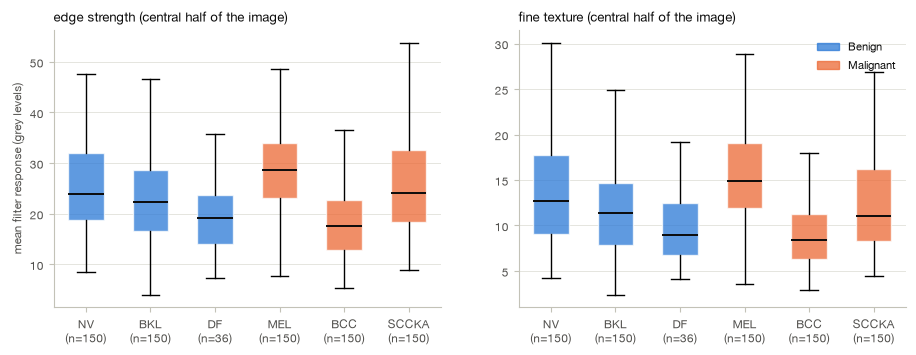

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, m in zip(axs, ["edge strength", "fine texture"]):
    data = [features.loc[features["dx"] == dx, m] for dx in CLASSES]
    box = ax.boxplot(data, patch_artist=True, widths=0.55, showfliers=False,
                     medianprops={"color": "#0b0b0b", "linewidth": 1.4})
    for patch, dx in zip(box["boxes"], CLASSES):
        group = "Benign" if dx in ("NV", "BKL", "DF") else "Malignant"
        patch.set_facecolor(CLASS_COLORS[group])
        patch.set_alpha(0.75)
        patch.set_edgecolor("white")
    ax.set_xticks(range(1, len(CLASSES) + 1),
                  [f"{dx}\n(n={(features['dx'] == dx).sum()})" for dx in CLASSES])
    ax.set_title(f"{m} (central half of the image)")
    ax.grid(axis="x", visible=False)
axs[0].set_ylabel("mean filter response (grey levels)")
axs[1].legend(handles=[Patch(color=CLASS_COLORS[g], alpha=0.75, label=g) for g in ("Benign", "Malignant")],
              loc="upper right")
show_and_save(fig, "part1_boxplots.png")

**Typical examples.** For each diagnosis, the image whose edge strength is closest to its class median (a typical
case, not a hand-picked one), shown on the central half. Sobel and outline use the **same grey scale in every row**,
so brighter = stronger edges / more texture can be compared between rows.

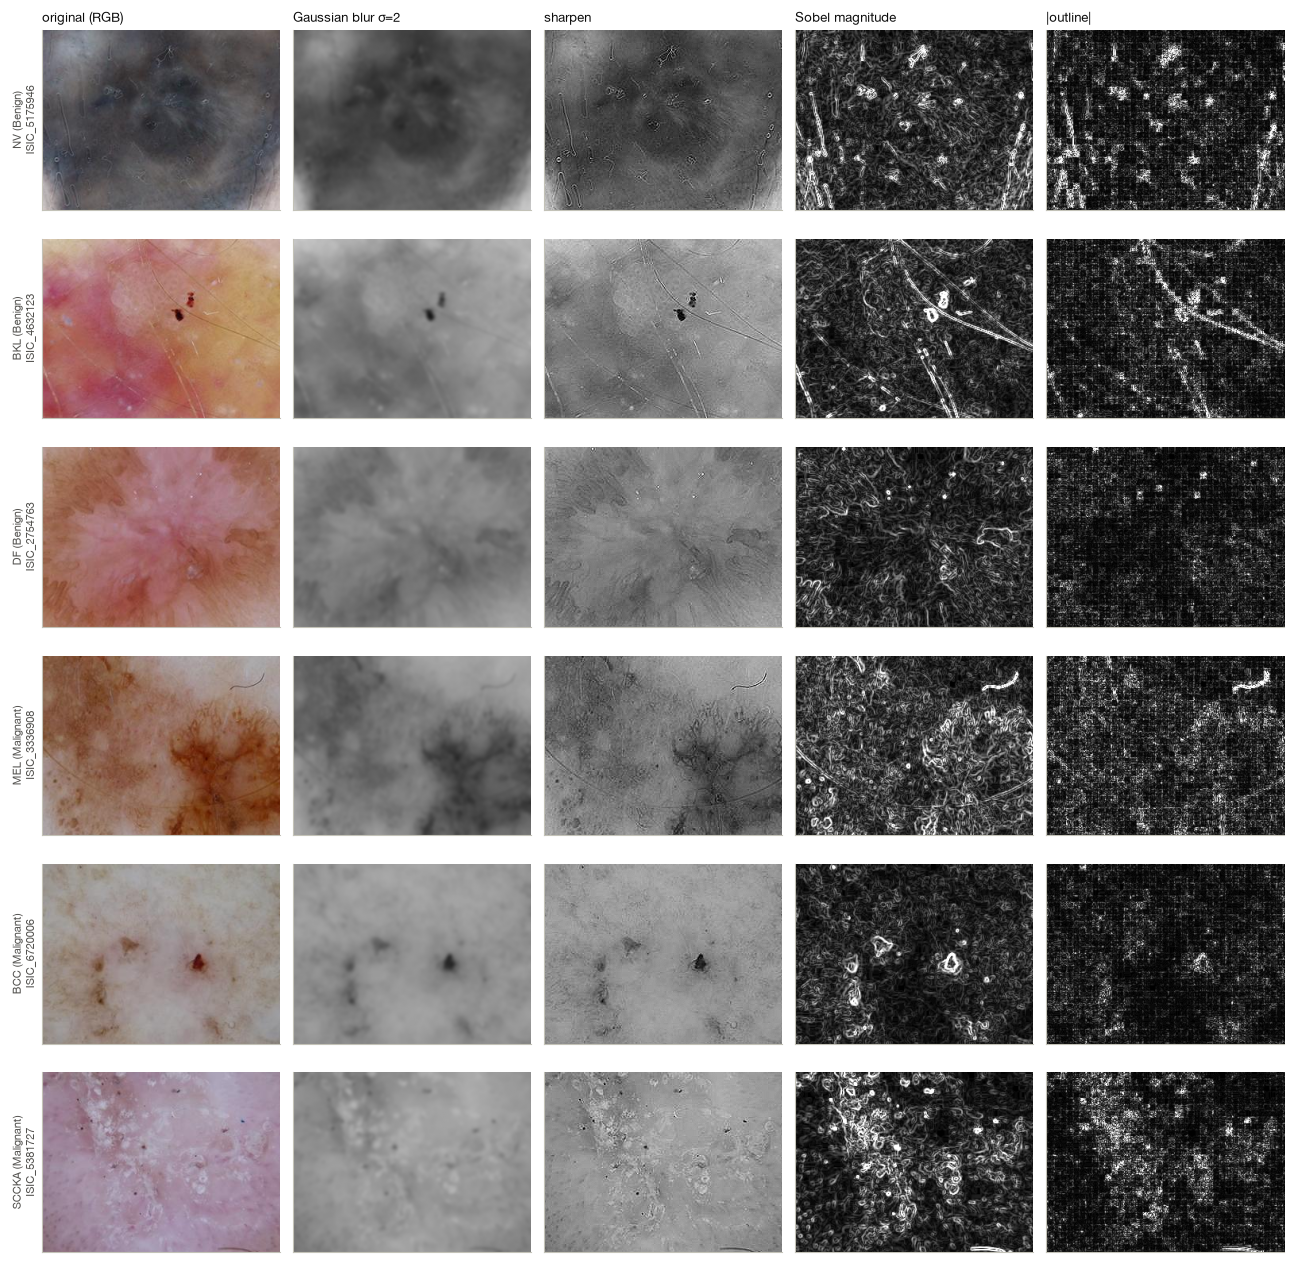

,isic_id,dx,diagnosis_1,edge strength,fine texture,contrast
23,ISIC_5175946,NV,Benign,23.8,14.2,23.9
222,ISIC_4632123,BKL,Benign,22.5,13.2,21.7
310,ISIC_2754763,DF,Benign,18.9,9.5,13.9
378,ISIC_3336908,MEL,Malignant,28.2,15.1,27.0
546,ISIC_6720006,BCC,Malignant,17.5,8.6,13.3
643,ISIC_5381727,SCCKA,Malignant,23.7,12.2,12.7


In [5]:
typical = features.loc[[(features.loc[features["dx"] == dx, "edge strength"]
                         - features.loc[features["dx"] == dx, "edge strength"].median()).abs().idxmin()
                        for dx in CLASSES]]
crops = {r.dx: load_gray(r.isic_id)[CENTRE] for r in typical.itertuples()}
sobel_max = np.percentile(np.concatenate([sobel_magnitude(c).ravel() for c in crops.values()]), 99)
outline_max = np.percentile(np.concatenate([np.abs(filt(c, OUTLINE)).ravel() for c in crops.values()]), 99)

fig, axs = plt.subplots(len(CLASSES), 5, figsize=(13, 2.15 * len(CLASSES)))
for i, r in enumerate(typical.itertuples()):
    c = crops[r.dx]
    panels = [(load_rgb(r.isic_id)[CENTRE], {}),
              (ndimage.gaussian_filter(c, 2), dict(cmap="gray", vmin=0, vmax=255)),
              (np.clip(filt(c, SHARPEN), 0, 255), dict(cmap="gray", vmin=0, vmax=255)),
              (sobel_magnitude(c), dict(cmap="gray", vmin=0, vmax=sobel_max)),
              (np.abs(filt(c, OUTLINE)), dict(cmap="gray", vmin=0, vmax=outline_max))]
    for j, (img, kw) in enumerate(panels):
        axs[i, j].imshow(img, **kw)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].grid(False)
    axs[i, 0].set_ylabel(f"{r.dx} ({r.diagnosis_1})\n{r.isic_id}", fontsize=8)
for j, title in enumerate(["original (RGB)", "Gaussian blur σ=2", "sharpen", "Sobel magnitude", "|outline|"]):
    axs[0, j].set_title(title)
plt.tight_layout()
show_and_save(fig, "part1_examples.jpg")
typical[["isic_id", "dx", "diagnosis_1"] + METRICS].round(1)

### Answer — Part 1

**Not as a simple Benign vs. Malignant split, but yes for specific diagnoses.**

- **Benign vs. Malignant (pooled): no difference.** AUC 0.51 for edge strength and 0.50 for fine texture (p = 0.5
  and 1). "Malignant" mixes opposite cases that cancel out: **BCC is the smoothest class** (median edge strength
  17.5, the lowest) and **melanoma the most textured** (28.5, the highest).
- **Melanoma vs. nevus** (both melanocytic, the clinically important pair): melanomas have **stronger edges and
  more fine texture** (median 28.5 vs. 23.8 and 14.9 vs. 12.7; AUC 0.63 for both, p < 0.001), while their overall
  contrast is the same (AUC 0.44, p = 0.09). The difference is in the lesion's *structure* (more and sharper local
  changes), not just a darker lesion. In the typical examples the melanoma row has the brightest Sobel and outline
  maps on the shared scale (edge strength 28.2, texture 15.1).
- **BCC vs. nevus:** BCCs have weaker edges (AUC 0.27), but above all **much lower contrast** (AUC 0.11). In
  grayscale a BCC is a faint, low-contrast lesion, so all its edge maps are dark.

**Caveat.** AUC 0.63 still means a large overlap: a melanoma has a higher edge strength than a random nevus only
63% of the time. One hand-made filter statistic is a weak feature on its own. Hairs, lighting and image contrast
also change it. Telling the classes apart needs many features combined (Session 5) or filters learned from the
data (CNN).

## Part 2 — Gaussian blur: what `sigma` controls

From the documentation of `scipy.ndimage.gaussian_filter(input, sigma, order=0, output=None, mode='reflect', cval=0.0, truncate=4.0, *, radius=None, axes=None)` (SciPy 1.17):

- **`sigma`**: *"Standard deviation for Gaussian kernel. The standard deviations of the Gaussian filter are given
  for each axis as a sequence, or as a single number, in which case it is equal for all axes."* It is measured in
  **pixels**; `sigma=(0, 8)` blurs only along axis 1.
- **`truncate`**: *"Truncate the filter at this many standard deviations. Default is 4.0."* The kernel has size
  `2*radius + 1` with `radius = round(truncate * sigma)` (9×9 for σ = 1, 33×33 for σ = 4); the `radius` argument
  can set it directly.
- Notes: *"The multidimensional filter is implemented as a sequence of 1-D convolution filters"*: the 2-D
  Gaussian is separable, so σ = 8 costs two passes of 65 weights instead of one of 65×65.
- `mode='reflect'` is the mirror padding from class (NumPy's `"symmetric"`); `order` > 0 filters with a derivative
  of the Gaussian instead (e.g. `order=1` = a smoothed gradient).

So `sigma` sets the **scale** of the blur: each output pixel is a weighted average over a neighbourhood about
2σ–3σ pixels in radius, and details much smaller than σ are averaged away.

The first check below rebuilds the filter from that description: a 2-D kernel made from the Gaussian formula
with radius `round(4σ)`, applied with plain correlation, must give the same image as `gaussian_filter`.

In [6]:
LESION_ID = "ISIC_0073863"                    # the lesion used in class (Reed nevus)
lesion = load_gray(LESION_ID)
SIGMAS = [0.5, 1, 2, 4, 8]


def gaussian_1d(sigma, truncate=4.0):
    """1-D Gaussian weights exp(-x² / 2σ²), cut at truncate·σ like scipy, normalised to sum 1."""
    radius = round(truncate * sigma)
    x = np.arange(-radius, radius + 1)
    g = np.exp(-x ** 2 / (2 * sigma ** 2))
    return g / g.sum()


rows = []
for s in SIGMAS:
    g = gaussian_1d(s)
    mine = filt(lesion, np.outer(g, g))                      # 2-D kernel = outer product of the 1-D one
    scipy_out = ndimage.gaussian_filter(lesion, sigma=s)
    rows.append({"sigma": s, "kernel size": f"{len(g)}×{len(g)}",
                 "max |mine - gaussian_filter|": np.abs(mine - scipy_out).max()})
pd.DataFrame(rows).set_index("sigma")

,kernel size,max |mine - gaussian_filter|
sigma,,
0.5,5×5,1.421085e-13
1.0,9×9,2.557954e-13
2.0,17×17,4.263256e-13
4.0,33×33,9.663381e-13
8.0,65×65,1.676881e-12


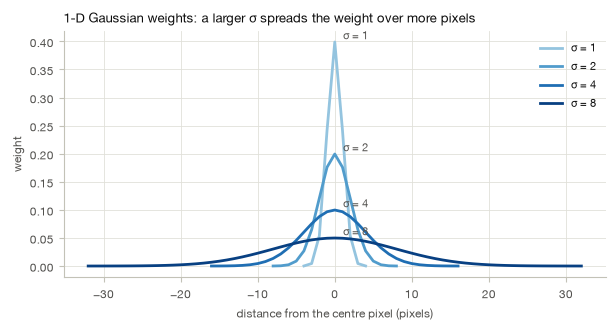

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))
blues = plt.get_cmap("Blues")
for i, s in enumerate([1, 2, 4, 8]):
    g = gaussian_1d(s)
    x = np.arange(len(g)) - len(g) // 2
    color = blues(0.4 + 0.18 * i)                            # one hue, light -> dark as sigma grows
    ax.plot(x, g, color=color, lw=2, label=f"σ = {s}")
    ax.annotate(f"σ = {s}", (0, g.max()), xytext=(6, 2), textcoords="offset points", fontsize=8, color="#52514e")
ax.set_xlabel("distance from the centre pixel (pixels)")
ax.set_ylabel("weight")
ax.set_title("1-D Gaussian weights: a larger σ spreads the weight over more pixels")
ax.legend()
show_and_save(fig, "part2_kernel_profiles.png")

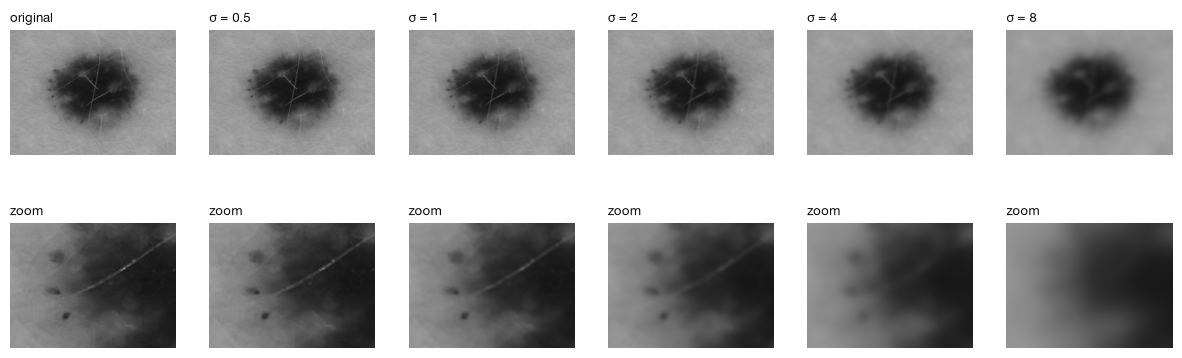

,kernel size,mean edge strength,% of the original
sigma,,,
0.0,-,16.4,100
0.5,5×5,14.9,91
1.0,9×9,11.8,72
2.0,17×17,8.2,50
4.0,33×33,5.5,34
8.0,65×65,4.2,25


In [8]:
ZOOM = (slice(150, 270), slice(100, 260))         # the lesion's left border and its inside (as in class)
blurred = {0: lesion} | {s: ndimage.gaussian_filter(lesion, sigma=s) for s in SIGMAS}

fig, axs = plt.subplots(2, len(blurred), figsize=(15, 4.6))
for j, (s, img) in enumerate(blurred.items()):
    axs[0, j].imshow(img, cmap="gray", vmin=0, vmax=255)
    axs[1, j].imshow(img[ZOOM], cmap="gray", vmin=0, vmax=255)
    axs[0, j].set_title("original" if s == 0 else f"σ = {s}")
    axs[1, j].set_title("zoom")
for ax in axs.ravel():
    ax.axis("off")
show_and_save(fig, "part2_sigma_series.jpg")

base = sobel_magnitude(lesion).mean()
pd.DataFrame([{"sigma": s, "kernel size": "-" if s == 0 else f"{2 * round(4 * s) + 1}×{2 * round(4 * s) + 1}",
               "mean edge strength": round(sobel_magnitude(img).mean(), 1),
               "% of the original": round(100 * sobel_magnitude(img).mean() / base)}
              for s, img in blurred.items()]).set_index("sigma")

**`sigma` per axis.** With a sequence, each axis gets its own σ. `sigma=(0, 8)` blurs only along axis 1 (left ↔
right), `sigma=(8, 0)` only along axis 0 (up ↔ down).

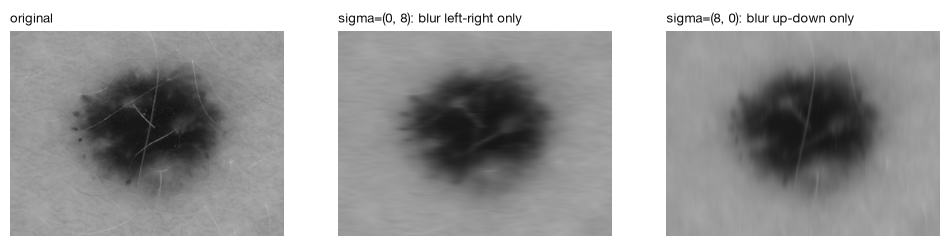

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, (title, img) in zip(axs, [("original", lesion),
                                  ("sigma=(0, 8): blur left-right only", ndimage.gaussian_filter(lesion, sigma=(0, 8))),
                                  ("sigma=(8, 0): blur up-down only", ndimage.gaussian_filter(lesion, sigma=(8, 0)))]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
show_and_save(fig, "part2_sigma_per_axis.jpg")

### Answer — Part 2

**`sigma` is the standard deviation of the Gaussian kernel, in pixels; it sets the *scale* of the blur.** It can be
one value or one value per axis.

- A larger σ gives a **wider bell** (kernel-profile figure): the weight is spread over more pixels and the centre
  pixel counts less. With the default `truncate=4.0` the kernel grows from 5×5 (σ = 0.5) to 65×65 (σ = 8).
- So each output pixel averages a **larger neighbourhood**, and structures smaller than about σ are averaged away.
  On lesion ISIC_0073863 the remaining edge strength is 91% at σ = 0.5, 72% at σ = 1, **50% at σ = 2**, 34% at
  σ = 4 and 25% at σ = 8.
- **Small σ (0.5–1)** removes pixel-level noise but keeps most of the lesion's detail. **Large σ (4–8)**
  keeps only the large-scale structure, i.e. the dark lesion against the skin; the fine internal structure is gone.
- **σ per axis**: `sigma=(0, 8)` blurs only left ↔ right and `sigma=(8, 0)` only up ↔ down, which stretches the image
  into streaks along one direction.
- The documentation's description is exact: a 2-D kernel built from the Gaussian formula with radius `round(4σ)`
  reproduces `gaussian_filter` to 10⁻¹². The filter is separable, i.e. computed as one 1-D pass per axis.

**In practice** σ is chosen from the size of the details to ignore. It is also the first step of Canny (Part 3),
where it decides which scale of edges is found.

## Part 3 — Canny edge detection, from scratch

Canny (1986) turns the gradient into **thin, connected, binary edges** in five steps:

1. **Smooth** with a Gaussian (σ) so noise does not create edges (Part 2).
2. **Gradient** with Sobel: magnitude $\sqrt{G_x^2 + G_y^2}$ and direction $\theta = \arctan(G_y / G_x)$.
3. **Non-maximum suppression**: keep a pixel only if its magnitude is the largest of its two neighbours
   *along the gradient direction* (rounded to 0°, 45°, 90° or 135°). A thick ridge becomes a 1-pixel line.
4. **Double threshold**: pixels above `high` are **strong** edges; pixels between `low` and `high` are **weak**.
5. **Hysteresis**: keep a weak pixel only if it is connected (8-neighbourhood) to a strong one, so an edge
   can continue through a faint stretch while isolated weak responses (noise) are dropped.

Here `low` and `high` are **quantiles** of the gradient magnitude (0.80 and 0.95: weak = top 20%, strong = top 5%),
which works for images of any contrast.

In [10]:
def canny(image, sigma=2.0, low=0.80, high=0.95):
    """Canny edge detector. low/high are quantiles of the gradient magnitude. Returns a boolean edge map."""
    # 1. smooth
    smooth = ndimage.gaussian_filter(image, sigma)
    # 2. gradient magnitude and direction (0-180°, a direction and its opposite are the same line)
    gx, gy = filt(smooth, SOBEL_X), filt(smooth, SOBEL_Y)
    magnitude = np.sqrt(gx ** 2 + gy ** 2)
    angle = np.rad2deg(np.arctan2(gy, gx)) % 180
    direction = (np.round(angle / 45) % 4).astype(int)        # 0: 0°, 1: 45°, 2: 90°, 3: 135°
    # 3. non-maximum suppression: compare with the two neighbours along the gradient
    h, w = magnitude.shape
    padded = np.pad(magnitude, 1)

    def neighbour(dr, dc):                                    # magnitude of the neighbour at (row+dr, col+dc)
        return padded[1 + dr:1 + dr + h, 1 + dc:1 + dc + w]

    steps = [(0, 1), (1, 1), (1, 0), (1, -1)]                  # (row, col) step for 0°, 45°, 90°, 135°
    is_max = np.zeros((h, w), dtype=bool)
    for d, (dr, dc) in enumerate(steps):
        is_max |= (direction == d) & (magnitude >= neighbour(dr, dc)) & (magnitude >= neighbour(-dr, -dc))
    thin = np.where(is_max, magnitude, 0)
    # 4. double threshold
    low_value, high_value = np.quantile(magnitude, [low, high])
    candidates = thin >= low_value                             # strong + weak
    strong = thin >= high_value
    # 5. hysteresis: keep the connected groups of candidates that contain at least one strong pixel
    groups, _ = ndimage.label(candidates, structure=np.ones((3, 3)))
    keep = np.unique(groups[strong])
    return np.isin(groups, keep[keep > 0])

**Check against a reference.** `skimage.feature.canny` with the same σ and the same quantile thresholds. It
interpolates the gradient direction instead of rounding it to 45°, so a few pixels differ by one position; the
fair comparison is the share of edge pixels that lie within 1 pixel of the other method's edges.

In [11]:
mine = canny(lesion, sigma=2)
reference = feature.canny(lesion, sigma=2, low_threshold=0.80, high_threshold=0.95, use_quantiles=True)


def share_within_1px(a, b):
    """Share of the edge pixels of a that are within 1 pixel of an edge pixel of b."""
    return (a & ndimage.binary_dilation(b, structure=np.ones((3, 3)))).sum() / a.sum()


print(f"edge pixels: mine {mine.mean() * 100:.2f}% of the image, skimage {reference.mean() * 100:.2f}%")
print(f"mine within 1 px of skimage: {share_within_1px(mine, reference):.0%}; "
      f"skimage within 1 px of mine: {share_within_1px(reference, mine):.0%}")

edge pixels: mine 2.50% of the image, skimage 2.46%
mine within 1 px of skimage: 97%; skimage within 1 px of mine: 97%


**Canny vs. Sobel on lesion ISIC_0073863.** The Sobel magnitude is a grey-level map; to compare like with like it
is also thresholded at the same level as Canny's strong edges (top 5% of the gradient), without thinning or
hysteresis.

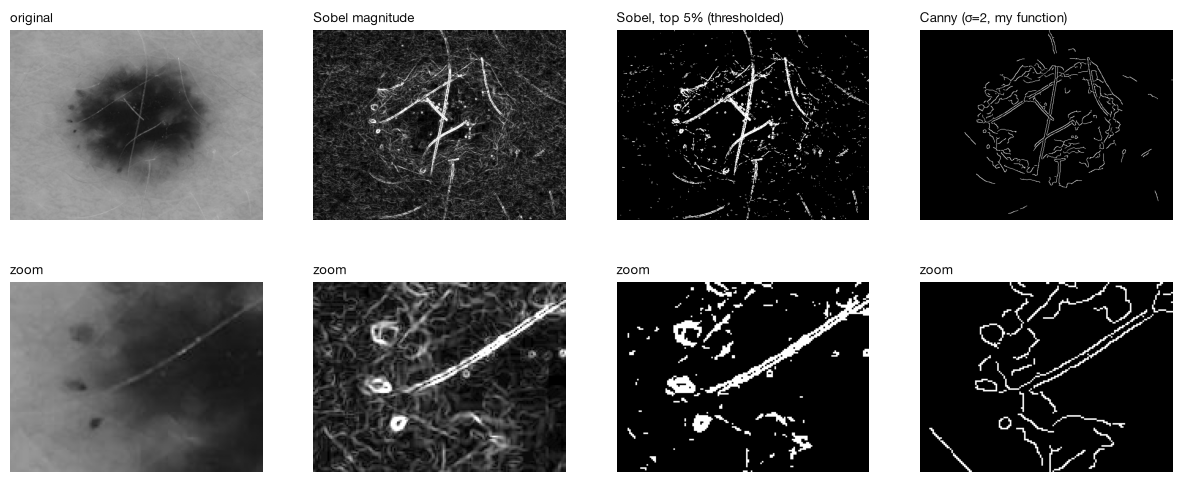

,Sobel top 5%,Canny
edge pixels (% of image),5.06,2.5
connected pieces,1099.00,171.0
median piece size (px),3.00,28.0
pieces of 1-2 px (isolated dots),545.00,10.0


In [12]:
sobel = sobel_magnitude(lesion)
sobel_top5 = sobel >= np.quantile(sobel, 0.95)

fig, axs = plt.subplots(2, 4, figsize=(15, 6))
panels = [("original", lesion, dict(cmap="gray", vmin=0, vmax=255)),
          ("Sobel magnitude", sobel, dict(cmap="gray", vmin=0, vmax=np.percentile(sobel, 99))),
          ("Sobel, top 5% (thresholded)", sobel_top5, dict(cmap="gray")),
          ("Canny (σ=2, my function)", mine, dict(cmap="gray"))]
for j, (title, img, kw) in enumerate(panels):
    axs[0, j].imshow(img, **kw)
    axs[1, j].imshow(img[ZOOM], **kw)
    axs[0, j].set_title(title)
    axs[1, j].set_title("zoom")
for ax in axs.ravel():
    ax.axis("off")
show_and_save(fig, "part3_canny_vs_sobel.jpg")


def describe(edges):
    groups, n = ndimage.label(edges, structure=np.ones((3, 3)))
    sizes = np.bincount(groups.ravel())[1:]
    return {"edge pixels (% of image)": round(edges.mean() * 100, 2), "connected pieces": n,
            "median piece size (px)": int(np.median(sizes)),
            "pieces of 1-2 px (isolated dots)": int((sizes <= 2).sum())}


pd.DataFrame({"Sobel top 5%": describe(sobel_top5), "Canny": describe(mine)})

**The effect of σ in Canny** (same thresholds): σ decides which *scale* of edge is found, exactly as in Part 2.

sigma 1: 4.73% edge pixels, 396 connected pieces
sigma 2: 2.50% edge pixels, 171 connected pieces
sigma 4: 1.15% edge pixels, 76 connected pieces


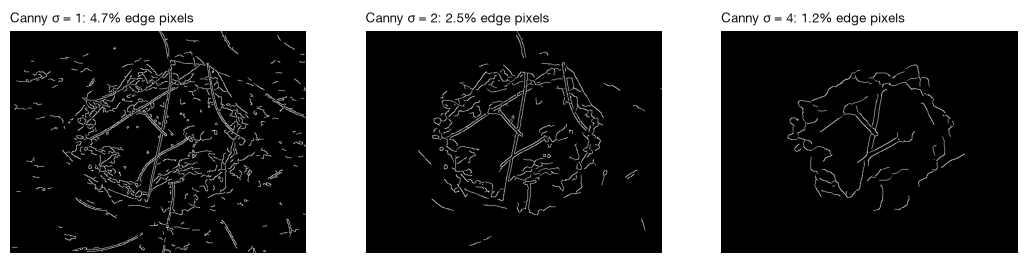

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, s in zip(axs, [1, 2, 4]):
    edges = canny(lesion, sigma=s)
    ax.imshow(edges, cmap="gray")
    ax.set_title(f"Canny σ = {s}: {edges.mean() * 100:.1f}% edge pixels")
    ax.axis("off")
    print(f"sigma {s}: {edges.mean() * 100:.2f}% edge pixels, {ndimage.label(edges, structure=np.ones((3, 3)))[1]} connected pieces")
show_and_save(fig, "part3_canny_sigma.jpg")

### Answer — Part 3: main differences between Canny and Sobel

My `canny` agrees with `skimage.feature.canny` (97% of edge pixels within 1 pixel, in both directions, and almost
the same number of edge pixels: 2.50% vs. 2.46%).

1. **Output.** Sobel gives a *grey-level* map: how strong the change is at every pixel. Canny gives a *binary*
   map: edge or not.
2. **Thickness.** Sobel edges are **thick bands** several pixels wide, because the gradient is high on both sides
   of an edge. Canny keeps only the ridge (non-maximum suppression), so its edges are **1-pixel lines**. At the same
   top-5% level, thresholded Sobel marks 5.06% of the pixels and Canny 2.50%.
3. **Continuity and noise.** Thresholded Sobel falls apart into **1,099 pieces** (median 3 pixels), 545 of them
   isolated 1–2-pixel dots from texture, noise and JPEG blocks. Thanks to the Gaussian smoothing and hysteresis,
   Canny gives **171 connected contours** (median 28 pixels) with only 10 isolated dots. The lesion outline and its
   internal structures become continuous lines.
4. **Control.** Sobel is a fixed 3×3 scale, and any threshold has to be chosen afterwards. Canny has a scale (σ)
   and two thresholds: σ = 1 marks 4.7% of the pixels in 396 pieces (fine internal detail), σ = 2 2.5% in 171, and
   σ = 4 1.15% in 76 (mostly the main outlines).
5. **Relation and cost.** Sobel is step 2 *inside* Canny. Canny adds smoothing, thinning and connectivity, which
   costs more computation but gives a cleaner, ready-to-use edge map.

**For the project.** Canny's clean, connected contours suit measuring the **shape of the lesion border** (border
irregularity). Sobel's magnitude suits **texture statistics** such as the mean edge strength used in Part 1.